# Convolutional Neural Networks

# Importar Librerías

In [1]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [2]:
import keras
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from keras.models import Sequential,Model
from tensorflow.keras.layers import Input
from keras.layers import Dense, Dropout, Flatten
#from keras.layers import Conv2D, MaxPooling2D
#from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    BatchNormalization, SeparableConv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense, Conv2D
)
from keras.layers import LeakyReLU

# Cargar set de Imágenes

In [3]:
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt
import os
import re

dirname = os.path.join(os.getcwd(), 'animales')
imgpath = dirname + os.sep

images = []
directories = []
dircount = []

print("leyendo y redimensionando imagenes a 128x128 de ", imgpath)

for root, dirnames, filenames in os.walk(imgpath):
    valid_files = [f for f in filenames if re.search(r'\.(jpg|jpeg|png|bmp|tiff)$', f, re.IGNORECASE)]
    if not valid_files:
        continue
    
    print(f"Leyendo directorio: {root} ({len(valid_files)} imágenes)")
    directories.append(root)
    dircount.append(len(valid_files))
    
    cant = 0
    for filename in valid_files:
        cant += 1
        filepath = os.path.join(root, filename)
        try:
            image = plt.imread(filepath)
            if len(image.shape) == 3:
                if image.max() <= 1.0 and image.dtype != np.uint8:
                    image = (image * 255).astype(np.uint8)
                if image.shape[-1] == 4:
                    image = image[:, :, :3]
                image_resized = resize(image, (128, 128), anti_aliasing=True, clip=False, preserve_range=True)
                images.append(image_resized)
        except Exception as e:
            print(f"Error al leer {filename}: {e}")
        
        if cant % 100 == 0:
            print(f"  Procesadas {cant}/{len(valid_files)}...")

print('Directorios leidos:', len(directories))
print("Imagenes en cada directorio", dircount)
print('suma Total de imagenes en subdirs:', sum(dircount))

# Creamos las etiquetas

In [4]:
labels=[]
indice=0
for cantidad in dircount:
    for i in range(cantidad):
        labels.append(indice)
    indice=indice+1
print("Cantidad etiquetas creadas: ",len(labels))


Cantidad etiquetas creadas:  6177


In [5]:
animales=[]
indice=0
for directorio in directories:
    name = directorio.split(os.sep)
    print(indice , name[len(name)-1])
    animales.append(name[len(name)-1])
    indice=indice+1

0 araña
1 ballena
2 mono
3 pajaro
4 rana


In [6]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8) #convierto de lista a numpy



# Find the unique numbers from the train labels
classes = np.unique(y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  5
Output classes :  [0 1 2 3 4]


# Creamos Sets de Entrenamiento y Test

In [7]:
train_X,test_X,train_Y,test_Y = train_test_split(X,y,test_size=0.2)
print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)

Training data shape :  (4941, 64, 64, 3) (4941,)
Testing data shape :  (1236, 64, 64, 3) (1236,)


Text(0.5, 1.0, 'Ground Truth : 0')

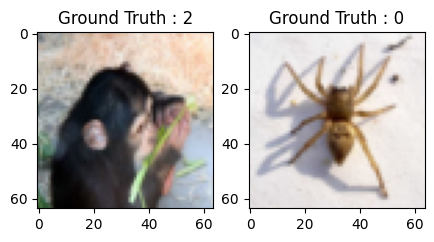

In [8]:
plt.figure(figsize=[5,5])

# Display the first image in training data
plt.subplot(121)
plt.imshow(train_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(train_Y[0]))

# Display the first image in testing data
plt.subplot(122)
plt.imshow(test_X[0,:,:], cmap='gray')
plt.title("Ground Truth : {}".format(test_Y[0]))

# Preprocesamos las imagenes

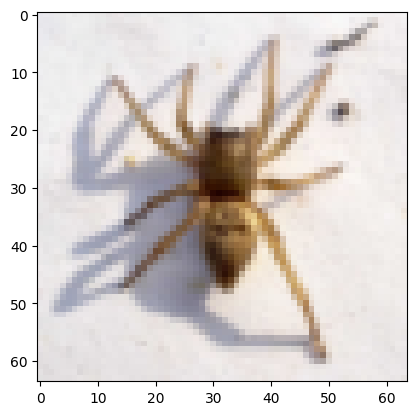

In [9]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')
train_X = train_X/255.
test_X = test_X/255.
plt.imshow(test_X[0,:,:])

## Hacemos el One-hot Encoding para la red

In [10]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Display the change for category label using one-hot encoding
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])

Original label: 2
After conversion to one-hot: [0. 0. 1. 0. 0.]


# Creamos el Set de Entrenamiento y Validación

In [11]:
#Mezclar todo y crear los grupos de entrenamiento y testing
train_X,valid_X,train_label,valid_label = train_test_split(train_X, train_Y_one_hot, test_size=0.2, random_state=13)

In [12]:
print(train_X.shape,valid_X.shape,train_label.shape,valid_label.shape)

(3952, 64, 64, 3) (989, 64, 64, 3) (3952, 5) (989, 5)


# Creamos el modelo de CNN

In [13]:
#declaramos variables con los parámetros de configuración de la red
INIT_LR = 1e-3 # Valor inicial de learning rate. El valor 1e-3 corresponde con 0.001
epochs = 35 # Cantidad de iteraciones completas al conjunto de imagenes de entrenamiento
batch_size = 64 # cantidad de imágenes que se toman a la vez en memoria

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense, BatchNormalization, Activation
import tensorflow as tf

animals_model = Sequential([
    Input(shape=(128, 128, 3)),
    
    # 1. Capas de Aumentación de Datos Avanzada
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
    
    # Bloque Convolucional 1
    Conv2D(32, kernel_size=(3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(32, kernel_size=(3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),
    
    # Bloque Convolucional 2
    Conv2D(64, kernel_size=(3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(64, kernel_size=(3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    # Bloque Convolucional 3
    Conv2D(128, kernel_size=(3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(128, kernel_size=(3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),
    
    # Bloque Convolucional 4
    Conv2D(256, kernel_size=(3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.4),
    
    # Clasificador Basado en Global Average Pooling (Evita Overfitting)
    GlobalAveragePooling2D(),
    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    Dense(nClasses, activation='softmax')
])


In [15]:
animals_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,163,493 (8.25 MB)

 Trainable params: 2,163,493 (8.25 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
animals_model.compile(loss=keras.losses.categorical_crossentropy, optimizer=tf.keras.optimizers.Adam(learning_rate=INIT_LR),metrics=['accuracy'])

# Entrenamos el modelo: Aprende a clasificar imágenes

In [ ]:
# Habilitar entrenamiento desde cero
force_retrain = True

import os
import keras
from sklearn.utils import class_weight

model_path = "animals_128_V3.keras"
model_path_legacy = "animals_128_V3.h5"
loaded_from_disk = False

if not force_retrain:
    if os.path.exists(model_path):
        print(f"Cargando modelo guardado de alta precisión (128x128) desde: {model_path}")
        animals_model = keras.models.load_model(model_path)
        loaded_from_disk = True
        print("¡Modelo cargado exitosamente del disco!")

if not loaded_from_disk:
    print("Iniciando entrenamiento del modelo 128x128 con regularización y class weights...")
    
    # 1. Calcular class weights automáticos
    train_labels_ints = np.argmax(train_label, axis=1)
    class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_labels_ints),
        y=train_labels_ints
    )
    class_weights_dict = dict(enumerate(class_weights))
    print(f"Pesos de clase calculados: {class_weights_dict}")
    
    # Callbacks (EarlyStopping de 8 épocas y ReduceLROnPlateau)
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
    ]
    
    # Entrenamos por las épocas definidas pasándole los pesos de clase
    animals_train = animals_model.fit(
        train_X, train_label, 
        batch_size=batch_size,
        epochs=epochs,
        verbose=1,
        validation_data=(valid_X, valid_label),
        callbacks=callbacks,
        class_weight=class_weights_dict
    )
    
    # Guardar los nuevos modelos entrenados a 128x128
    print("Guardando nuevo modelo optimizado...")
    animals_model.save(model_path)
    animals_model.save(model_path_legacy)
    print("Modelos guardados exitosamente como animals_128_V3.keras y animals_128_V3.h5!")
else:
    animals_train = None


In [ ]:
# guardamos la red, para reutilizarla en el futuro, sin tener que volver a entrenar
print("Guardando modelo en formato moderno .keras y legacy .h5...")
animals_model.save("animals_V3.keras")
animals_model.save("animals_V3.h5")
print("¡Modelo guardado exitosamente como animals_V3.keras y animals_V3.h5!")


## Historial de Entrenamiento

Graficamos la precisión y pérdida del entrenamiento. Si el modelo se cargó directamente del disco, esta sección se saltará de forma segura.

In [19]:
test_eval = animals_model.evaluate(test_X, test_Y_one_hot, verbose=1)

 1/39 ━━━━━━━━━━━━━━━━━━━━ 23s 628ms/step - accuracy: 0.8438 - loss: 0.2222

 2/39 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.8359 - loss: 0.2618  

 4/39 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8372 - loss: 0.2979

 6/39 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8401 - loss: 0.3233

 8/39 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8477 - loss: 0.3247

...

35/39 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8698 - loss: 0.3305

36/39 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8696 - loss: 0.3313

37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8694 - loss: 0.3321

38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8692 - loss: 0.3329

39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8625 - loss: 0.3571


In [20]:
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 0.35706180334091187
Test accuracy: 0.8624595403671265


In [21]:
if 'animals_train' in globals() and animals_train is not None:
    animals_train.history
else:
    print("Historial de entrenamiento no disponible (modelo cargado directamente desde disco).")

Historial de entrenamiento no disponible (modelo cargado directamente desde disco).


In [22]:
if 'animals_train' in globals() and animals_train is not None:
    accuracy = animals_train.history['accuracy']
    val_accuracy = animals_train.history['val_accuracy']
    loss = animals_train.history['loss']
    val_loss = animals_train.history['val_loss']
    epochs_range = range(len(accuracy))
    
    plt.plot(epochs_range, accuracy, 'bo', label='Training accuracy')
    plt.plot(epochs_range, val_accuracy, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.figure()
    plt.plot(epochs_range, loss, 'bo', label='Training loss')
    plt.plot(epochs_range, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()
    plt.show()
else:
    print("El modelo fue cargado directamente del disco, por lo que no hay historial de entrenamiento disponible para graficar.")

El modelo fue cargado directamente del disco, por lo que no hay historial de entrenamiento disponible para graficar.


In [23]:
predicted_classes2 = animals_model.predict(test_X)

 1/39 ━━━━━━━━━━━━━━━━━━━━ 8s 234ms/step

 2/39 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step 

 4/39 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step

 6/39 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step

 7/39 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step

...

36/39 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

37/39 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

38/39 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step

39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step


In [24]:
predicted_classes=[]
for predicted_animal in predicted_classes2:
    predicted_classes.append(predicted_animal.tolist().index(max(predicted_animal)))
predicted_classes=np.array(predicted_classes)

In [25]:
predicted_classes.shape, test_Y.shape

((1236,), (1236,))

# Aprendamos de los errores: Qué mejorar

Found 1066 correct labels


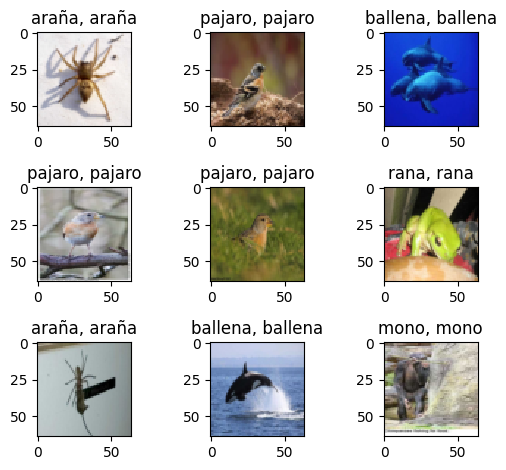

In [26]:
correct = np.where(predicted_classes==test_Y)[0]
print("Found %d correct labels" % len(correct))
for i, idx in enumerate(correct[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[idx].reshape(128,128,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(animales[predicted_classes[idx]],
                                                    animales[test_Y[idx]]))

    plt.tight_layout()

Found 170 incorrect labels


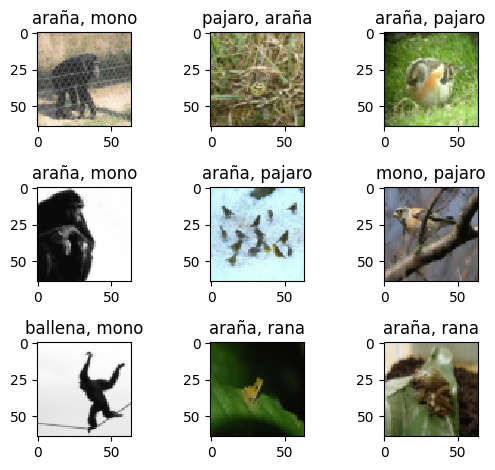

In [27]:
incorrect = np.where(predicted_classes!=test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))
for i, idx in enumerate(incorrect[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[idx].reshape(128,128,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(animales[predicted_classes[idx]],
                                                    animales[test_Y[idx]]))
    plt.tight_layout()

In [28]:
target_names = ["Class {}".format(i) for i in range(nClasses)]
print(classification_report(test_Y, predicted_classes, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.76      0.88      0.82       299
     Class 1       0.99      0.90      0.94       209
     Class 2       0.89      0.86      0.88       240
     Class 3       0.81      0.85      0.83       258
     Class 4       0.95      0.82      0.88       230

    accuracy                           0.86      1236
   macro avg       0.88      0.86      0.87      1236
weighted avg       0.87      0.86      0.86      1236



## Matriz de confusion

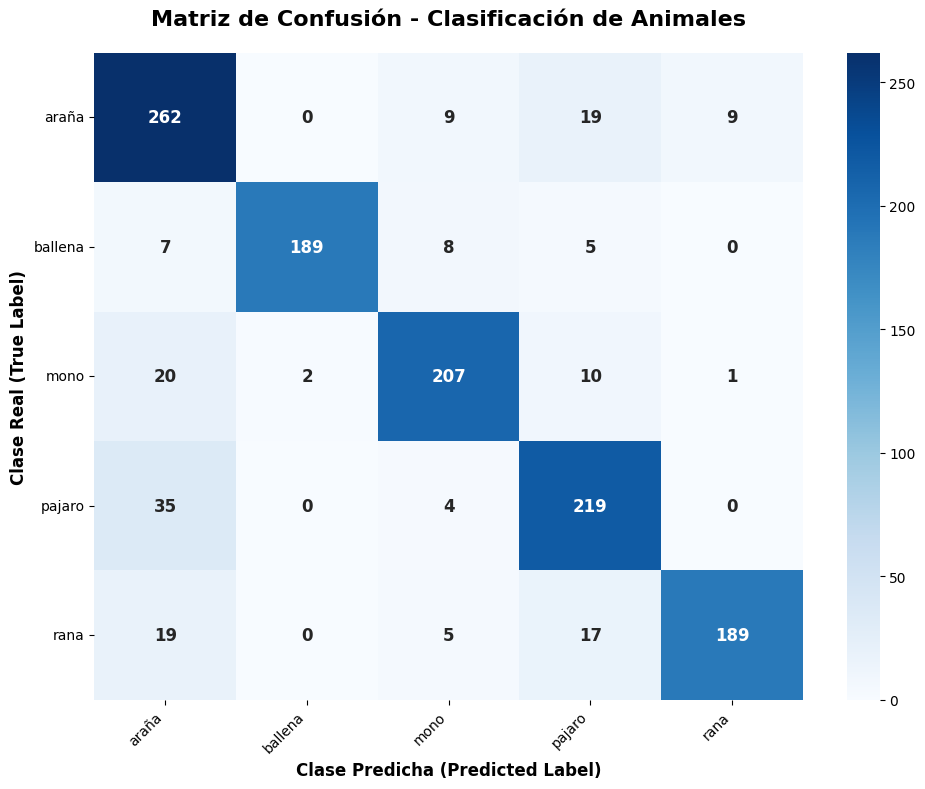

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcular la matriz de confusión usando las etiquetas reales y predichas
cm = confusion_matrix(test_Y, predicted_classes)

# 2. Graficar la matriz de confusión de manera visual y profesional
try:
    import seaborn as sns
    plt.figure(figsize=(10, 8))
    # Usamos una paleta de colores azul sofisticada y premium
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=animales, yticklabels=animales,
                annot_kws={"size": 12, "weight": "bold"})
    plt.title('Matriz de Confusión - Clasificación de Animales', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Clase Real (True Label)', fontsize=12, fontweight='bold')
    plt.xlabel('Clase Predicha (Predicted Label)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()
except ImportError:
    # Si seaborn no está instalado, usamos la visualización nativa de scikit-learn
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=animales)
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
    plt.title('Matriz de Confusión - Clasificación de Animales', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Clase Real (True Label)', fontsize=12, fontweight='bold')
    plt.xlabel('Clase Predicha (Predicted Label)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [30]:
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt
import os
import keras

# Intentamos cargar el modelo guardado de 128x128 del disco para no tener que volver a entrenar
model_path = "animals_128_V2.keras"
model_path_legacy = "animals_128_V2.h5"

if os.path.exists(model_path):
    print(f"Cargando modelo guardado (128x128) desde: {model_path}")
    animals_model = keras.models.load_model(model_path)
    print("¡Modelo de 128x128 cargado exitosamente!")
elif os.path.exists(model_path_legacy):
    print(f"Cargando modelo guardado (legacy 128x128) desde: {model_path_legacy}")
    animals_model = keras.models.load_model(model_path_legacy)
    print("¡Modelo de 128x128 cargado exitosamente!")
else:
    print("ADVERTENCIA: No se encontró un modelo de 128x128 guardado en el disco. Se usará el modelo en memoria activa.")

import re

test2_dir = r'C:\Users\crist\Desktop\TEC\Semestre_9\IA\Proyectos-IA\CNN\test2'
filenames = []
if os.path.exists(test2_dir):
    for f in os.listdir(test2_dir):
        if re.search(r'\.(jpg|jpeg|png|bmp|tiff|webp|avif)$', f, re.IGNORECASE):
            filenames.append(os.path.join(test2_dir, f))

images = []

for filepath in filenames:
    if not os.path.exists(filepath):
        print(f"Archivo no encontrado: {filepath}")
        continue
    image = plt.imread(filepath)
    
    # Si la imagen se lee en rango [0.0, 1.0], la escalamos a [0, 255]
    if image.max() <= 1.0 and image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8)
        
    # Manejar canales de imagen: RGBA -> RGB o Escala de grises -> RGB
    if len(image.shape) == 2:
        image = np.stack([image] * 3, axis=-1)
    elif image.shape[-1] == 4:
        image = image[:, :, :3]
        
    image_resized = resize(image, (128, 128), anti_aliasing=True, clip=False, preserve_range=True)
    images.append(image_resized)

if len(images) > 0:
    X = np.array(images, dtype=np.uint8) #convierto de lista a numpy
    test_X = X.astype('float32')
    test_X = test_X / 255.

    predicted_classes2 = animals_model.predict(test_X)

    predicted_classes = []
    for predicted_animal in predicted_classes2:
        predicted_classes.append(predicted_animal.tolist().index(max(predicted_animal)))
    predicted_classes = np.array(predicted_classes)

    for i, img_tagged in enumerate(predicted_classes2):
        confidence = max(img_tagged) * 100
        predicted_idx = img_tagged.tolist().index(max(img_tagged))
        print(f"{filenames[i]} -> Predicción: {animales[predicted_idx]} ({confidence:.2f}%)")
else:
    print("No hay imágenes válidas para evaluar.")


Cargando modelo guardado desde: animals.keras


¡Modelo cargado exitosamente!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


C:\Users\crist\Desktop\TEC\Semestre_9\IA\Proyectos-IA\CNN\test\pajaro.jpg -> Predicción: pajaro (42.09%)
C:\Users\crist\Desktop\TEC\Semestre_9\IA\Proyectos-IA\CNN\test\pajaro2.jpg -> Predicción: mono (53.91%)
C:\Users\crist\Desktop\TEC\Semestre_9\IA\Proyectos-IA\CNN\test\hormiga3.webp -> Predicción: rana (61.81%)
